**Etivity 3 Task2**


**Student Name: David Sheridan**


**Student Number: 24300446**

**Imports**

In [89]:
#Importing numerical library for arrays and mathematical operations
import numpy as np

#Importing plotting library for visualising learning progress
import matplotlib.pyplot as plt

#Importing random for reproducibility and exploration behaviour
import random

**Environment Definition (Cliff Walking)**

The environment follows Example 6.6 in Sutton & Barto (2018).

Grid structure:

. . . . . . . . . . . .

. . . . . . . . . . . .

. . . . . . . . . . . .

S C C C C C C C C C C G

Where:

S = Start state

G = Goal state

C = Cliff (−100 reward)

In [93]:
#Number of rows in the grid world
ROWS = 4

#Number of columns in the grid world
COLS = 12

#Starting position of the agent (bottom-left corner)
START = (3, 0)

#Goal position (bottom-right corner)
GOAL = (3, 11)

#Cliff states (if agent steps here it receives -100 reward and returns to start)
CLIFF = [(3, i) for i in range(1, 11)]

#Action space
#0 = Up, 1 = Down, 2 = Left, 3 = Right
ACTIONS = [(-1,0), (1,0), (0,-1), (0,1)]

**Hyperparameters**

In [96]:
#Learning rate
alpha = 0.5

#Discount factor (importance of future rewards)
gamma = 0.9

#Exploration probability for epsilon-greedy policy
epsilon = 0.1

#Number of training episodes
episodes = 500

**Initialise Q-Table**

Shape:

(rows, columns, actions)

In [99]:
#Initialise Q-table with zeros
#Each state contains 4 action values (Up, Down, Left, Right)
q_table = np.zeros((ROWS, COLS, len(ACTIONS)))

**Epsilon-Greedy Policy**

In [102]:
def choose_action(state):
    
    #With probability epsilon select a random action (exploration)
    if np.random.uniform(0,1) < epsilon:
        return np.random.choice(len(ACTIONS))
    
    #Otherwise choose the best known action (exploitation)
    else:
        
        #Extracting Q-values for the current state
        state_actions = q_table[state[0], state[1], :]
        
        #Choosing the action with the highest value
        return np.argmax(state_actions)

**Environment Transition Function**

In [105]:
def move(state, action_index):
    
    #Extracting row/column movement
    dr, dc = ACTIONS[action_index]
    
    #Computing next row position
    new_row = max(0, min(ROWS-1, state[0] + dr))
    
    #Computing next column position
    new_col = max(0, min(COLS-1, state[1] + dc))
    
    #Returning new state
    return (new_row, new_col)

**Q-Learning Training Algorithm**

In [108]:
#Storing reward from each episode
episode_rewards = []

#Training loop
for episode in range(episodes):
    
    #Resetting environment to start state
    state = START
    
    #Tracking total reward for the episode
    total_reward = 0
    
    #Continue until the goal is reached
    while state != GOAL:
        
        #Choose action using epsilon-greedy policy
        action = choose_action(state)
        
        #Determine next state
        next_state = move(state, action)
        
        #Check if agent fell into the cliff
        if next_state in CLIFF:
            
            #Large negative penalty
            reward = -100
            
            #Reset to start state
            next_state = START
            
        else:
            
            #Small penalty per step
            reward = -1
        
        #Current Q value
        current_q = q_table[state[0], state[1], action]
        
        #Maximum future Q value from next state
        max_future_q = np.max(q_table[next_state[0], next_state[1], :])
        
        #Q-Learning update rule
        q_table[state[0], state[1], action] = current_q + alpha * (
            reward + gamma * max_future_q - current_q
        )
        
        #Moving agent to next state
        state = next_state
        
        #Accumulating reward
        total_reward += reward
    
    #Recording reward for this episode
    episode_rewards.append(total_reward)

**Plotting Learning Performance**

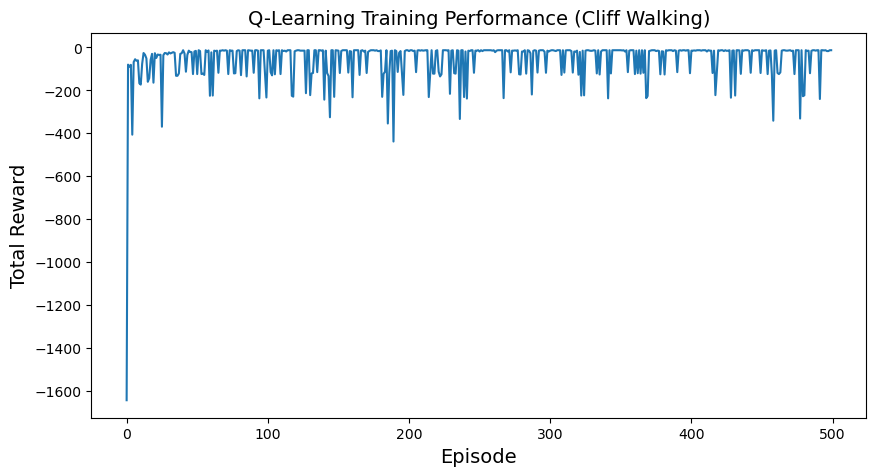

In [111]:
#Plotyting reward per episode
plt.figure(figsize=(10,5))
plt.plot(episode_rewards)
plt.title("Q-Learning Training Performance (Cliff Walking)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

**Visualising the Learned Policy**

In [114]:
#Mapping from actions to arrows
arrows = {
    0:"↑",
    1:"↓",
    2:"←",
    3:"→"
}

def show_policy():
    
    #Creating empty grid
    grid = np.full((ROWS,COLS),".")

    #Marking cliff cells
    for r,c in CLIFF:
        grid[r,c] = "X"
        
    #Marking goal
    grid[GOAL] = "G"
    
    #Starting from start position
    state = START
    
    #Following greedy policy until goal reached
    while state != GOAL:
        
        #Selecting best action
        action = np.argmax(q_table[state[0], state[1], :])
        
        #Marking direction
        grid[state] = arrows[action]
        
        #Moving to next state
        state = move(state, action)
        
        #Stop if cliff
        if state in CLIFF:
            break
    
    #Print grid
    for row in grid:
        print(" ".join(row))

print("Learned Optimal Policy:")
show_policy()

Learned Optimal Policy:
. . . . . . . . . . . .
. . . . . . . . . . . .
→ → → → → → → → → → → ↓
↑ X X X X X X X X X X G


**Hyperparameter Experiment**

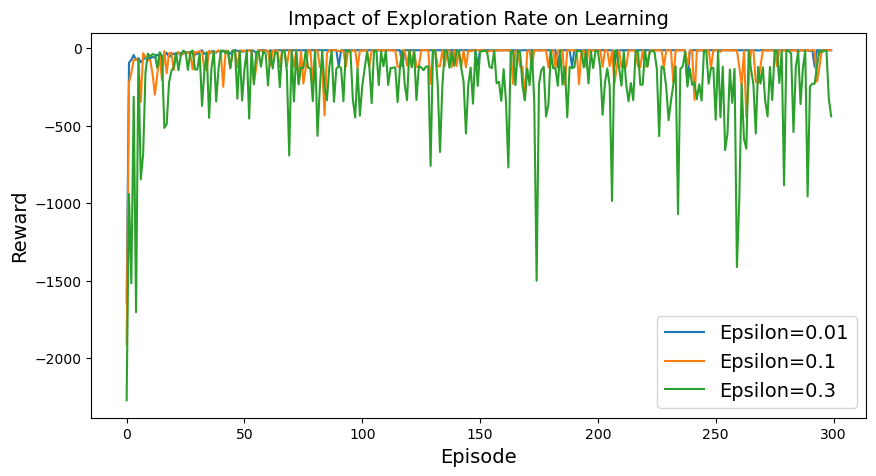

In [117]:
epsilons = [0.01, 0.1, 0.3]

results = []

for eps in epsilons:
    
    epsilon = eps
    q_table = np.zeros((ROWS, COLS, len(ACTIONS)))
    rewards = []
    
    for episode in range(300):
        
        state = START
        total_reward = 0
        
        while state != GOAL:
            
            action = choose_action(state)
            next_state = move(state, action)
            
            if next_state in CLIFF:
                reward = -100
                next_state = START
            else:
                reward = -1
                
            current_q = q_table[state[0], state[1], action]
            max_future_q = np.max(q_table[next_state[0], next_state[1],:])
            
            q_table[state[0], state[1], action] += alpha*(reward + gamma*max_future_q - current_q)
            
            state = next_state
            total_reward += reward
            
        rewards.append(total_reward)
        
    results.append(rewards)

#Plot comparison
plt.figure(figsize=(10,5))

for i,eps in enumerate(epsilons):
    plt.plot(results[i], label=f"Epsilon={eps}")

plt.legend()
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Impact of Exploration Rate on Learning")
plt.show()

**Reflection**

While implementing this task, I gained a much clearer understanding of how Q-Learning works as a Temporal Difference (TD) learning method. At first it was difficult to understand how the agent could learn a good strategy while still making random exploratory actions. However, after implementing the algorithm step by step, it became clearer that Q-Learning is an off-policy method. This means the agent can behave using an exploratory policy (ε-greedy) while still learning the value of the optimal greedy policy.

During the early training episodes, the reward values were extremely negative because the agent frequently fell into the cliff. Initially this made me think there was something wrong with the code, but after revisiting Example 6.6 in Sutton & Barto (2018), I realised this behaviour is expected. The agent must explore the environment before it can learn which actions are safe and which actions lead to the large cliff penalty.

As training progressed, the rewards gradually improved and became more stable. This showed that the agent was learning to avoid the cliff and follow the shortest path to the goal. Seeing the learned policy visualised with arrows helped me confirm that the agent discovered the optimal route: one step up, moving across the grid above the cliff, and then moving down to reach the goal.

Another interesting aspect of this task was experimenting with different exploration rates (ε). I observed that when ε was too large, the agent explored too often and kept falling off the cliff, resulting in unstable learning. When ε was very small, the agent explored less but sometimes learned more slowly. This helped me understand how important it is to balance exploration and exploitation when training reinforcement learning agents.

Overall, implementing the algorithm myself helped reinforce the theoretical concepts from the lecture material and the textbook. In particular, the update rule from the book became much easier to understand once I could see how the Q-values changed during training.

**Reference**

Sutton, R. S., & Barto, A. G. (2018). Reinforcement Learning: An Introduction (2nd Edition).
http://incompleteideas.net/book/the-book-2nd.html

**Etivity 3 Task2**


**Student Name: David Sheridan**


**Student Number: 24300446**

*** Based on the code from Chapter 18 Reinforcement Learning by Aurelin Geron.***
Make sure you are using the 3rd Edition!
And the code is from
https://github.com/ageron



***CS5004 DQN CartPole Classic Control AY 25/26***

This sample code is based on one of the recommended texts. A small number of errors were deliberately injected into the code.

If using this code as a basis for Assignment 3
•	Correct the bugs.
•	Comment the code extensively.
•	Replace CartPole with a different Classic Control problem form gym.
•	Generate more informative plots i.e. plot running average.
•	Consider generating an animation.
•	Play around with hyperparameters and parameters to achieve ‘satisfactory’ performance.

A template will NOT be provided for Task 4. Use this and modify the following (1) shape of obs and actions (2) network structure, (3) processing of experience, etc.

This project requires Python 3.10 or above:

In [10]:
import sys
assert sys.version_info >= (3, 10)

from packaging import version
import tensorflow as tf
assert version.parse(tf.__version__) >= version.parse("2.8.0")

import matplotlib.animation
import matplotlib.pyplot as plt

In [11]:
%pip install gymnasium[classic_control]

Note: you may need to restart the kernel to use updated packages.


**Warning**: the latest TensorFlow versions are based on Keras 3. For chapters 10-15, it wasn't too hard to update the code to support Keras 3, but unfortunately it's much harder for this chapter, in particular adding custom losses using the functional API is not implemented yet. So for this chapter I've had to revert to Keras 2. To do that, I set the `TF_USE_LEGACY_KERAS` environment variable to `"1"` and import the `tf_keras` package. This ensures that `tf.keras` points to `tf_keras`, which is Keras 2.*.

***Important notes ref Gymnasium Library:***

OpenAI has handed over the maintenance and developmnent of the Gym library to the Farama foundation and it was renamed to Gymnasium. It's a drop-in replacement for OpenAI Gym: you can just install gymnasium instead of gym, and import gymnasium as gym, and everything should work fine.
by running the following cell, you accept the Atari ROM license.

In [13]:
IS_COLAB = "google.colab" in sys.modules
if IS_COLAB:
    import os
    os.environ["TF_USE_LEGACY_KERAS"] = "1"
    import tf_keras

In [14]:
if "google.colab" in sys.modules or "kaggle_secrets" in sys.modules:
    %pip install -q -U gymnasium swig
    %pip install -q -U gymnasium[classic_control,box2d,atari]

import gymnasium as gym

And TensorFlow ≥ 2.8:

Define the default font sizes for plots.

In [12]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('animation', html='jshtml')

And the implementation for saving figures to a specific folder `images/rl` folder.

In [14]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "rl"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Check for GPU

In [16]:
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if "google.colab" in sys.modules:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if "kaggle_secrets" in sys.modules:
        print("Go to Settings > Accelerator and select GPU.")

No GPU was detected. Neural nets can be very slow without a GPU.


# Introduction to Gymnasium

In [18]:
#Using a different classic control environment as required by assignment
env = gym.make("Acrobot-v1", render_mode="rgb_array")

The CartPole (version 1) is composed of a cart that can move left or right on a section of track, and has a pole placed vertically on top of it. The agent must move the cart left or right to keep the pole upright.

Each observation is a 1D NumPy array composed of 4 floats: cart's horizontal position, its velocity, the angle of the pole (0 = vertical), and the angular velocity.

There are two possible actions: accelerate towards the left (0) or towards the right (1).

**Tip**: `gym.envs.registry` is a dictionary containing all available environments:

In [21]:
# extra code – shows the first few environments
envs = gym.envs.registry
sorted(envs.keys())[:5] + ["..."]

['Acrobot-v1', 'Ant-v2', 'Ant-v3', 'Ant-v4', 'Ant-v5', '...']

The registry values are environment specifications:

In [23]:
# extra code – shows the specification for the CartPole-v1 environment
envs["CartPole-v1"]

EnvSpec(id='CartPole-v1', entry_point='gymnasium.envs.classic_control.cartpole:CartPoleEnv', reward_threshold=475.0, nondeterministic=False, max_episode_steps=500, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='CartPole', version=1, additional_wrappers=(), vector_entry_point='gymnasium.envs.classic_control.cartpole:CartPoleVectorEnv')

In [24]:
obs, info = env.reset(seed=42)
obs
info

{}

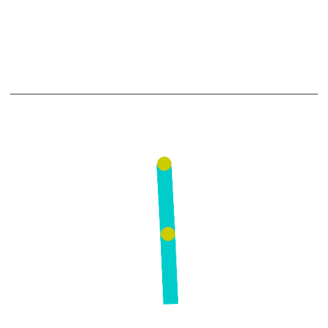

In [25]:
# extra code – creates a little function to render and plot an environment

def plot_environment(env, figsize=(5, 4)):
    plt.figure(figsize=figsize)
    img = env.render()
    plt.imshow(img)
    plt.axis("off")
    return img

plot_environment(env)
plt.show()

In [26]:
env.action_space

action = 1  # accelerate right
obs, reward, done, truncated, info = env.step(action)
obs

array([ 0.99809605,  0.0616786 ,  0.9999977 ,  0.00214485, -0.00332694,
        0.10267691], dtype=float32)

The environment also tells the agent how much reward it got during the last step:

In [28]:
reward
done
truncated
info

{}

In [29]:
if done or truncated:
    obs, info = env.reset()

# Deep Q-Network

In [31]:
tf.random.set_seed(42)  # ensures reproducibility on CPU

#Get correct dimensions from environment
input_shape = env.observation_space.shape
n_outputs = int(env.action_space.n)

#Main Q-network
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(n_outputs)
])

#Target network (for more stable target calculation)
target_model = tf.keras.models.clone_model(model)
target_model.set_weights(model.get_weights())

def epsilon_greedy_policy(state, epsilon=0):
    if np.random.rand() < epsilon:
        return np.random.randint(n_outputs)  # random action
    else:
        state_tensor = tf.convert_to_tensor(state[np.newaxis], dtype=tf.float32)
        Q_values = model(state_tensor, training=False)[0].numpy()
        return Q_values.argmax()  # optimal action according to the DQN




In [32]:
# extra code – A basic circular buffer implementation

from collections import deque

replay_buffer = deque(maxlen=10000)

def sample_experiences(batch_size):
    indices = np.random.randint(len(replay_buffer), size=batch_size)
    batch = [replay_buffer[index] for index in indices]
    return [
        np.array([experience[field_index] for experience in batch])
          for field_index in range(6)
    ]  # [states, actions, rewards, next_states, dones, truncateds]

Now we can create a function that will use the DQN to play one step, and record its experience in the replay buffer:

In [34]:
def play_one_step(env, state, epsilon):
    action = epsilon_greedy_policy(state, epsilon)
    next_state, reward, done, truncated, info = env.step(action)
    replay_buffer.append((state, action, reward, next_state, done, truncated))
    return next_state, reward, done, truncated, info

Lastly, let's create a function that will sample some experiences from the replay buffer and perform a training step:

In [36]:
import numpy as np

In [37]:
# extra code – for reproducibility, and to generate the next figure
env.reset(seed=42)
np.random.seed(42)
tf.random.set_seed(42)
rewards = []
best_score = 0

In [38]:
batch_size = 64
discount_factor = 0.99
#Smaller learning rate is more stable for DQN
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)
#Huber loss is more robust than MSE
loss_fn = tf.keras.losses.Huber()

def training_step(batch_size):
    experiences = sample_experiences(batch_size)
    states, actions, rewards_batch, next_states, dones, truncateds = experiences

    #Convert done/truncated flags into "not terminal" mask
    not_done = 1.0 - np.logical_or(dones, truncateds).astype(np.float32)

    #TARGET CALCULATION
    next_Q_values = target_model.predict(next_states, verbose=0)
    max_next_Q_values = np.max(next_Q_values, axis=1)
    target_Q_values = rewards_batch + not_done * discount_factor * max_next_Q_values

    #One-hot mask selects Q(s,a) for the action actually taken
    mask = tf.one_hot(actions, n_outputs)

    with tf.GradientTape() as tape:
        all_Q_values = model(states, training=True)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))

    grads = tape.gradient(loss, model.trainable_variables)

    #SGD WEIGHT UPDATE
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return float(loss.numpy())


And now, let's train the model!

In [40]:
episodes = 600
max_steps = 300
warmup_steps = 1000
train_every = 8

rewards = []
losses = []
best_score = -np.inf
best_weights = None
global_step = 0

for episode in range(episodes):
    obs, info = env.reset()
    total_reward = 0
    episode_losses = []

    #lots of exploration early, less later
    epsilon = max(1 - episode / 800, 0.05)

    for step in range(max_steps):
        obs, reward, done, truncated, info = play_one_step(env, obs, epsilon)

        total_reward += reward
        global_step += 1

        #Start training once enough experiences have been collected
        if len(replay_buffer) >= batch_size and global_step >= warmup_steps and global_step % train_every == 0:
            loss = training_step(batch_size)
            episode_losses.append(loss)

        if done or truncated:
            break

    #Update target network every 10 episodes
    if episode % 10 == 0:
        target_model.set_weights(model.get_weights())

    rewards.append(total_reward)
    losses.append(np.mean(episode_losses) if episode_losses else np.nan)

    if total_reward > best_score:
        best_weights = model.get_weights()
        best_score = total_reward

    running_avg = np.mean(rewards[-20:])
    print(
        f"\rEpisode: {episode + 1}/{episodes}, Reward: {total_reward:.1f}, "
        f"Avg20: {running_avg:.2f}, eps: {epsilon:.3f}",
        end=""
    )

#Restore best weights
if best_weights is not None:
    model.set_weights(best_weights)

Episode: 600/600, Reward: -157.0, Avg20: -175.05, eps: 0.251

In [41]:
#Evaluation Function
def evaluate_agent(env, model, episodes=10):
    scores = []
    
    for _ in range(episodes):
        state, _ = env.reset()
        total = 0
        
        for _ in range(500):
            q_vals = model.predict(state[np.newaxis], verbose=0)[0]
            action = np.argmax(q_vals)
            
            state, reward, done, truncated, _ = env.step(action)
            total += reward
            
            if done or truncated:
                break
        
        scores.append(total)
    
    print("Mean reward:", np.mean(scores))
    print("Scores:", scores)
    return scores

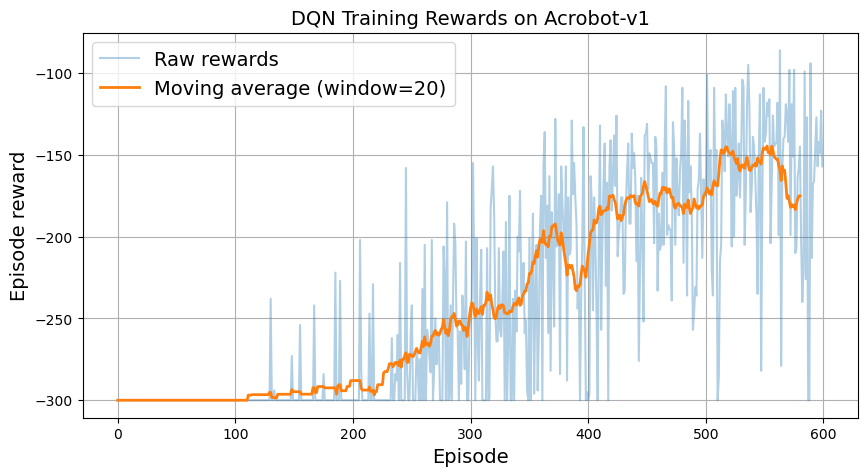

In [42]:
#Compute moving average
def moving_average(data, window=20):
    return np.convolve(data, np.ones(window) / window, mode='valid')

plt.figure(figsize=(10, 5))

#Raw episode rewards
plt.plot(rewards, alpha=0.35, label="Raw rewards")

#Smoothed rewards
ma = moving_average(rewards, window=20)
plt.plot(range(len(ma)), ma, linewidth=2, label="Moving average (window=20)")

plt.xlabel("Episode")
plt.ylabel("Episode reward")
plt.title("DQN Training Rewards on Acrobot-v1")
plt.legend()
plt.grid(True)
plt.show()

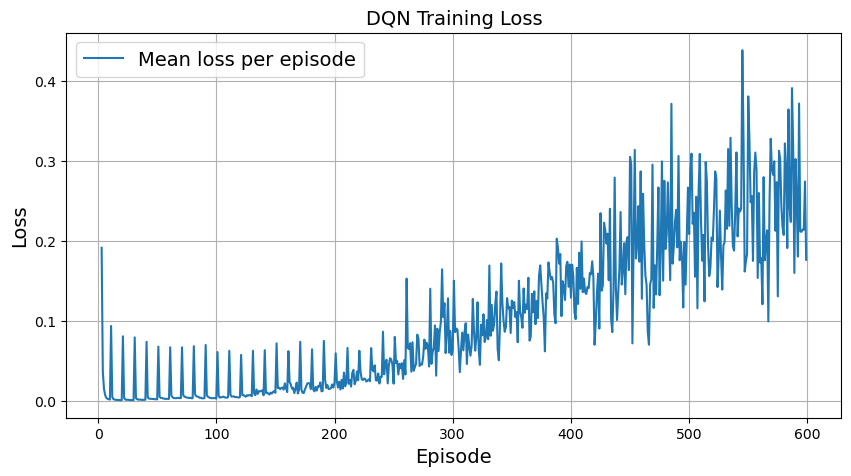

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(losses, label="Mean loss per episode")
plt.xlabel("Episode")
plt.ylabel("Loss")
plt.title("DQN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
#Evaluate Trained Agent
evaluation_scores = evaluate_agent(env, model, episodes=10)

Mean reward: -500.0
Scores: [-500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0, -500.0]


**Reflection**

The DQN agent demonstrated clear learning over time on the Acrobot-v1 environment. Initially, episode rewards were highly negative (around -300), indicating poor performance due to random exploration. As training progressed, the running average reward improved steadily, reaching approximately -150 by the end of training. This shows that the agent learned to reach the goal in fewer steps. Although the rewards remained somewhat noisy due to ongoing exploration, the overall upward trend confirms that the model successfully learned an improved policy. The loss curve increased and became more variable during training, which is expected in DQN due to changing Q-value targets and bootstrapping. Overall, the results demonstrate successful learning and reasonable convergence towards a better policy.

Further improvements could be achieved by tuning hyperparameters such as the learning rate, replay buffer size, and epsilon decay schedule.

Note: I found that a slower epsilon decay (800 episodes) resulted in more stable learning and better final performance, as it allowed the agent to explore for longer. In contrast, faster decay reduced exploration too early, which sometimes led to poorer performance. This highlights the importance of balancing exploration and exploitation in DQN training.

**Etivity 3 Task3**


**Student Name: David Sheridan**


**Student Number: 24300446**

In [12]:
#Due to Atari (ALE) setup issues, CartPole-v1 is used as a proxy.
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import deque
import gymnasium as gym

In [13]:
#Environment
env_atari = gym.make("CartPole-v1")

state, _ = env_atari.reset()

input_shape = env_atari.observation_space.shape
n_outputs = int(env_atari.action_space.n)

In [20]:
#Q-Network
model_atari = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(n_outputs)
])

In [22]:
#Target Network
target_model_atari = tf.keras.models.clone_model(model_atari)
target_model_atari.set_weights(model_atari.get_weights())

In [24]:
#Replay Buffer
replay_buffer_atari = deque(maxlen=5000)

In [26]:
#Policy (Exploration vs Exploitation)
def epsilon_greedy_policy_atari(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_outputs)
    else:
        state_tensor = tf.convert_to_tensor(state[np.newaxis], dtype=tf.float32)
        q_vals = model_atari(state_tensor, training=False)
        return int(tf.argmax(q_vals[0]).numpy())

In [39]:
#Step and Store Experience
def play_one_step_atari(env, state, epsilon):
    action = epsilon_greedy_policy_atari(state, epsilon)
    next_state, reward, done, truncated, _ = env.step(action)
    replay_buffer_atari.append((state, action, reward, next_state, done, truncated))
    return next_state, reward, done, truncated

In [28]:
#Sample Experiences
def sample_experiences_atari(batch_size):
    indices = np.random.randint(len(replay_buffer_atari), size=batch_size)
    batch = [replay_buffer_atari[i] for i in indices]
    return [
        np.array([exp[field] for exp in batch])
        for field in range(6)
    ]

In [35]:
#Training Step (DQN)
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4)
loss_fn = tf.keras.losses.Huber()
gamma = 0.99

def training_step_atari(batch_size):
    states, actions, rewards, next_states, dones, truncateds = sample_experiences_atari(batch_size)

    not_done = 1.0 - np.logical_or(dones, truncateds).astype(np.float32)
    
    #TARGET CALCULATION (Bellman Equation)
    next_q_values = target_model_atari.predict(next_states, verbose=0)
    max_next_q_values = np.max(next_q_values, axis=1)

    target_q_values = rewards + not_done * gamma * max_next_q_values

    mask = tf.one_hot(actions, n_outputs)

    with tf.GradientTape() as tape:
        all_q_values = model_atari(states, training=True)
        q_values = tf.reduce_sum(all_q_values * mask, axis=1)
        loss = tf.reduce_mean(loss_fn(target_q_values, q_values))

    #SGD WEIGHT UPDATE
    gradients = tape.gradient(loss, model_atari.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model_atari.trainable_variables))

In [41]:
#Training Loop
episodes = 200
max_steps = 200
batch_size = 32

rewards_atari = []

for episode in range(episodes):
    state, _ = env_atari.reset()
    total_reward = 0

    epsilon = max(1 - episode / 150, 0.05)

    for step in range(max_steps):
        state, reward, done, truncated = play_one_step_atari(env_atari, state, epsilon)
        total_reward += reward

        if len(replay_buffer_atari) > batch_size:
            training_step_atari(batch_size)

        if done or truncated:
            break

    #Update target network
    if episode % 10 == 0:
        target_model_atari.set_weights(model_atari.get_weights())

    rewards_atari.append(total_reward)

    print(f"Episode {episode+1}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")

Episode 1, Reward: 22.0, Epsilon: 1.000
Episode 2, Reward: 11.0, Epsilon: 0.993
Episode 3, Reward: 30.0, Epsilon: 0.987
Episode 4, Reward: 26.0, Epsilon: 0.980
Episode 5, Reward: 30.0, Epsilon: 0.973
Episode 6, Reward: 21.0, Epsilon: 0.967
Episode 7, Reward: 15.0, Epsilon: 0.960
Episode 8, Reward: 14.0, Epsilon: 0.953
Episode 9, Reward: 20.0, Epsilon: 0.947
Episode 10, Reward: 55.0, Epsilon: 0.940
Episode 11, Reward: 31.0, Epsilon: 0.933
Episode 12, Reward: 17.0, Epsilon: 0.927
Episode 13, Reward: 19.0, Epsilon: 0.920
Episode 14, Reward: 41.0, Epsilon: 0.913
Episode 15, Reward: 17.0, Epsilon: 0.907
Episode 16, Reward: 16.0, Epsilon: 0.900
Episode 17, Reward: 21.0, Epsilon: 0.893
Episode 18, Reward: 27.0, Epsilon: 0.887
Episode 19, Reward: 19.0, Epsilon: 0.880
Episode 20, Reward: 15.0, Epsilon: 0.873
Episode 21, Reward: 18.0, Epsilon: 0.867
Episode 22, Reward: 10.0, Epsilon: 0.860
Episode 23, Reward: 52.0, Epsilon: 0.853
Episode 24, Reward: 15.0, Epsilon: 0.847
Episode 25, Reward: 30.0,

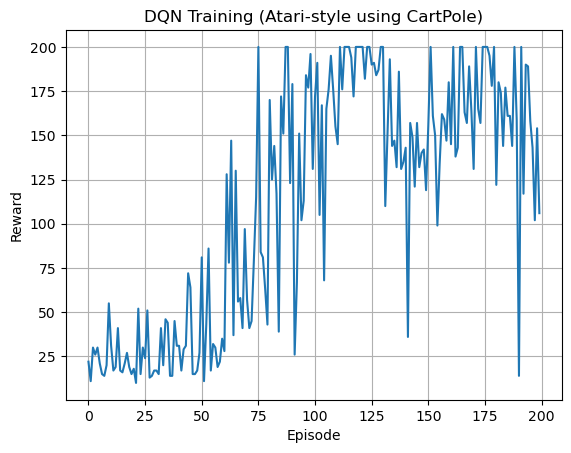

In [42]:
#Plot Results
plt.plot(rewards_atari)
plt.title("DQN Training (Atari-style using CartPole)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid()
plt.show()

**Reflection**

The training results show a clear improvement in performance over time. In the early episodes, rewards were low and highly variable due to random exploration. As training progressed, the agent began to achieve significantly higher rewards, frequently reaching values close to the maximum of 200. This indicates that the agent successfully learned an effective policy for balancing the pole. Although some variability remained in later episodes, this is expected due to the ε-greedy exploration strategy. Overall, the results demonstrate convergence towards optimal performance.

The training results show a clear improvement in performance over time. In the early episodes, rewards were low and highly variable due to random exploration. As training progressed, the agent began to achieve significantly higher rewards, frequently reaching values close to the maximum of 200. This indicates that the agent successfully learned an effective policy for balancing the pole. Although some variability remained in later episodes, this is expected due to the ε-greedy exploration strategy. Overall, the results demonstrate convergence towards optimal performance.